UPLOAD YOUR HR CSV FILE


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv

DATA LOADED SUCCESSFULLY
Rows: 1470
Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



DATA QUALITY
Missing values: 0
Duplicate rows: 0

================ KPI =================
Total Employees : 1470
Attrition Count : 237
Attrition Rate  : 16.12 %
Average Income  : 6502.93
Average Tenure  : 7.01 years


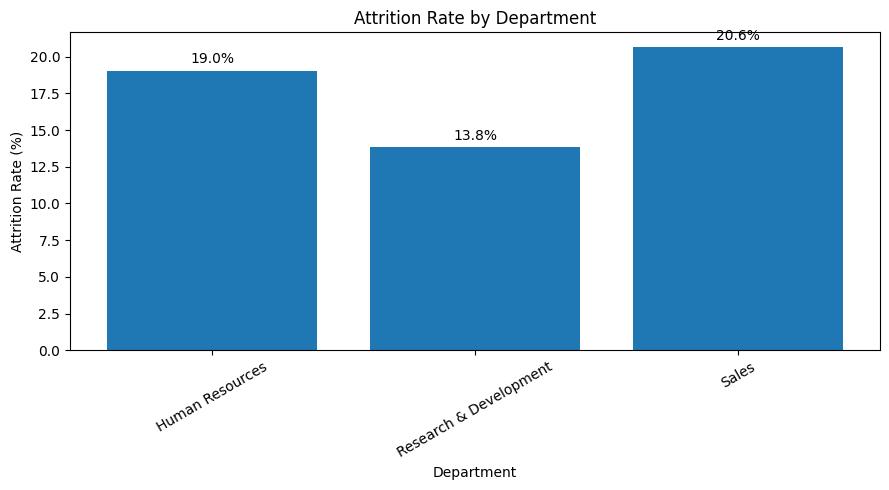

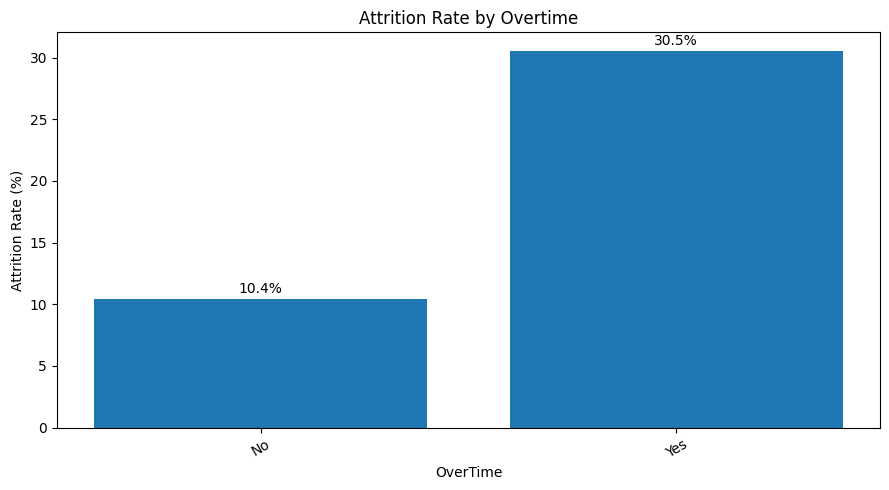

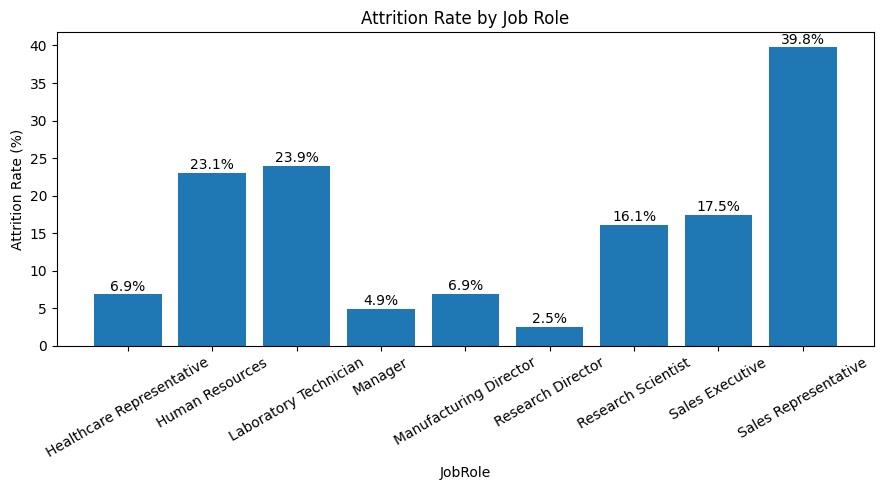

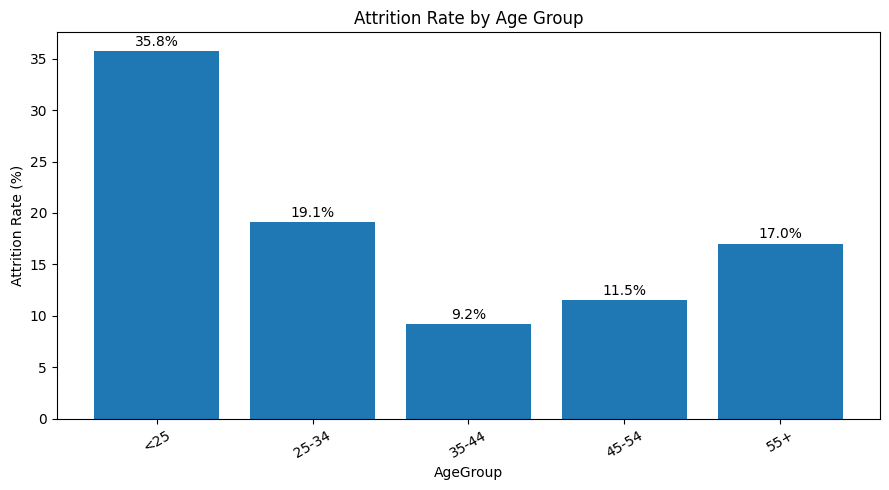

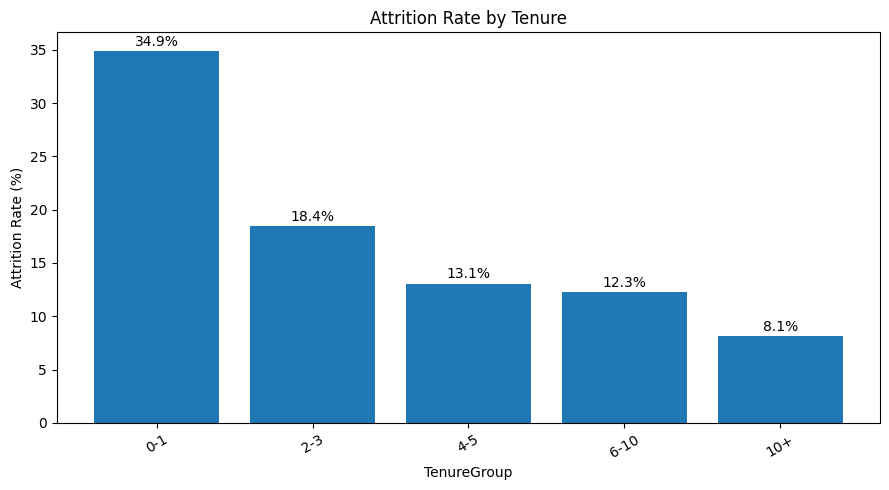

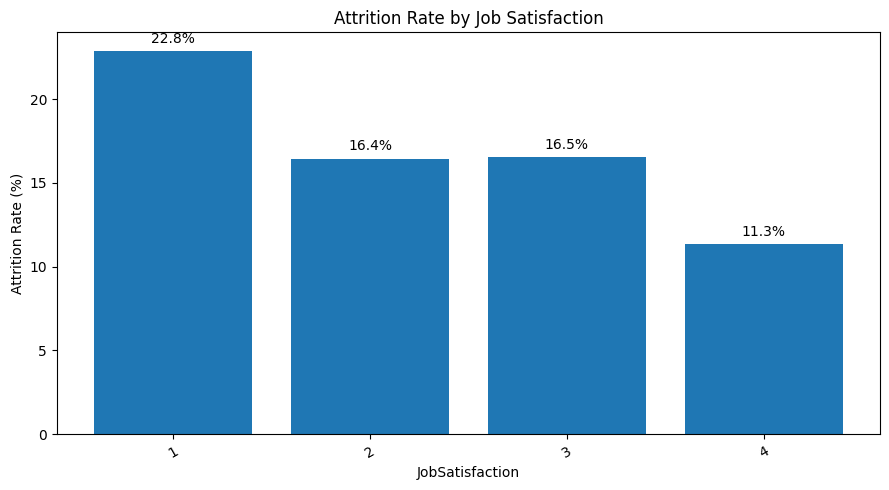


TRAINING MODEL...

================ MODEL RESULTS ================
Accuracy : 0.7483
Precision: 0.3483
Recall   : 0.6596
F1 Score : 0.4559


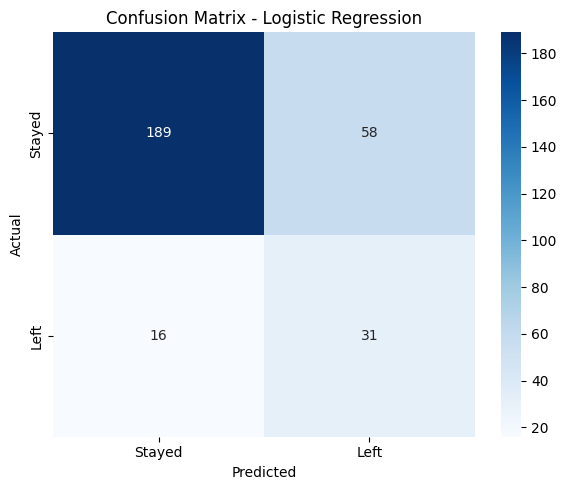


TOP ATTRITION FACTORS


,Feature,Coefficient,Importance
46,categorical__OverTime_Yes,1.628474,1.628474
26,categorical__BusinessTravel_Travel_Frequently,1.597583,1.597583
37,categorical__JobRole_Laboratory Technician,1.569270,1.569270
43,categorical__JobRole_Sales Representative,1.274779,1.274779
40,categorical__JobRole_Research Director,-1.103945,1.103945
33,categorical__EducationField_Other,-1.024883,1.024883
27,categorical__BusinessTravel_Travel_Rarely,0.906046,0.906046
45,categorical__MaritalStatus_Single,0.842848,0.842848
36,categorical__JobRole_Human Resources,0.630743,0.630743
19,numeric__TotalWorkingYears,-0.609027,0.609027


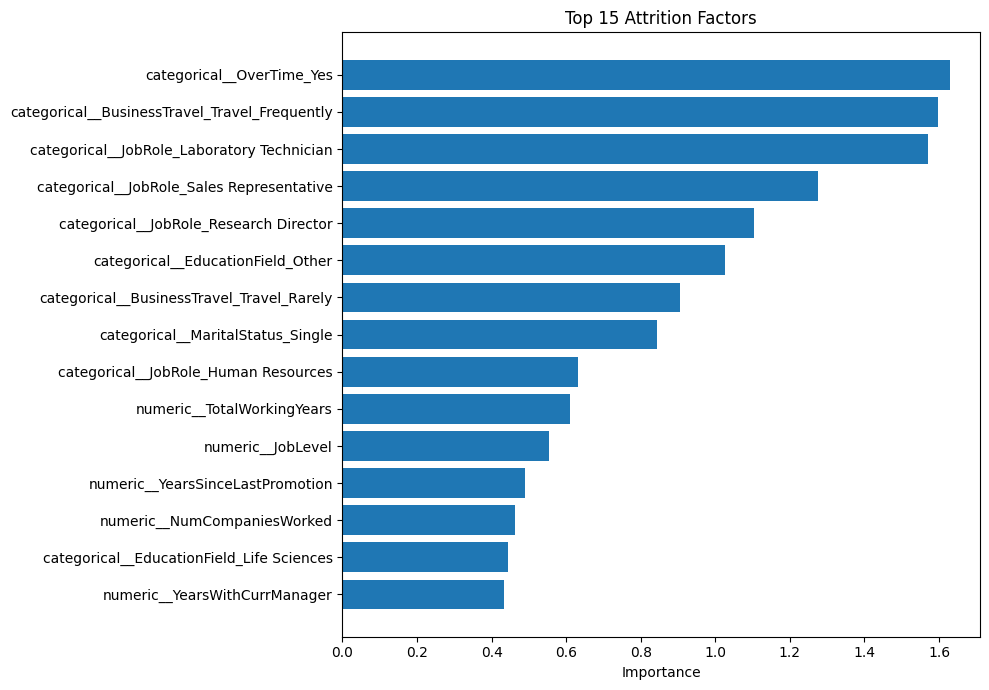


================ BUSINESS INSIGHTS ================
Overall employee attrition rate is 16.12%.
Average employee tenure is 7.01 years.
Average monthly income is 6502.93.
Highest department attrition rate: Sales (20.63%).
Highest job-role attrition rate: Sales Representative (39.76%).
Highest age-group attrition rate: <25 (35.77%).
Highest tenure-group attrition rate: 0-1 (34.88%).

RECOMMENDATIONS:
1. Monitor employees working overtime.
2. Improve employee career development opportunities.
3. Review compensation and salary progression.
4. Improve employee engagement and satisfaction.
5. Focus retention programs on high-risk departments and roles.

PROJECT ANALYSIS COMPLETED!

Files created:
HR_Attrition_PowerBI.csv
Feature_Importance.csv
Model_Metrics.csv


In [1]:
# ============================================================
# HR EMPLOYEE ATTRITION PROJECT - FAST VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from google.colab import files
import os

# ============================================================
# 1. UPLOAD CSV
# ============================================================

print("UPLOAD YOUR HR CSV FILE")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDATA LOADED SUCCESSFULLY")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

# ============================================================
# 2. DATA CLEANING
# ============================================================

print("\nDATA QUALITY")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

df["AttritionFlag"] = (
    df["Attrition"].str.lower() == "yes"
).astype(int)

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,25,35,45,55,100],
    labels=["<25","25-34","35-44","45-54","55+"]
)

df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1,1,3,5,10,100],
    labels=["0-1","2-3","4-5","6-10","10+"]
)

# ============================================================
# 4. KPI RESULTS
# ============================================================

employees = len(df)
attrition_count = df["AttritionFlag"].sum()
attrition_rate = df["AttritionFlag"].mean() * 100
avg_income = df["MonthlyIncome"].mean()
avg_tenure = df["YearsAtCompany"].mean()

print("\n================ KPI =================")
print("Total Employees :", employees)
print("Attrition Count :", attrition_count)
print("Attrition Rate  :", round(attrition_rate,2), "%")
print("Average Income  :", round(avg_income,2))
print("Average Tenure  :", round(avg_tenure,2), "years")

# ============================================================
# 5. EDA
# ============================================================

def attrition_chart(column, title):

    result = (
        df.groupby(column, observed=False)["AttritionFlag"]
        .mean() * 100
    )

    plt.figure(figsize=(9,5))
    plt.bar(result.index.astype(str), result.values)

    plt.title(title)
    plt.ylabel("Attrition Rate (%)")
    plt.xlabel(column)

    for i,v in enumerate(result.values):
        plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return result


department = attrition_chart(
    "Department",
    "Attrition Rate by Department"
)

overtime = attrition_chart(
    "OverTime",
    "Attrition Rate by Overtime"
)

jobrole = attrition_chart(
    "JobRole",
    "Attrition Rate by Job Role"
)

agegroup = attrition_chart(
    "AgeGroup",
    "Attrition Rate by Age Group"
)

tenure = attrition_chart(
    "TenureGroup",
    "Attrition Rate by Tenure"
)

satisfaction = attrition_chart(
    "JobSatisfaction",
    "Attrition Rate by Job Satisfaction"
)

# ============================================================
# 6. MACHINE LEARNING
# ============================================================

X = df.drop(
    columns=[
        "Attrition",
        "AttritionFlag",
        "AgeGroup",
        "TenureGroup"
    ]
)

y = df["AttritionFlag"]

categorical = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric
    ),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical
    )
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

print("\nTRAINING MODEL...")

model.fit(X_train, y_train)

prediction = model.predict(X_test)

# ============================================================
# 7. MODEL RESULTS
# ============================================================

accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    prediction,
    zero_division=0
)

print("\n================ MODEL RESULTS ================")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

pre = model.named_steps["preprocessor"]

feature_names = pre.get_feature_names_out()

coefficients = (
    model.named_steps["model"].coef_[0]
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTOP ATTRITION FACTORS")

display(
    importance.head(15)
)

plt.figure(figsize=(10,7))

top = importance.head(15).sort_values(
    "Importance"
)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Top 15 Attrition Factors")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# ============================================================
# 10. SAVE RESULTS
# ============================================================

df.to_csv(
    "HR_Attrition_PowerBI.csv",
    index=False
)

importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

metrics = pd.DataFrame({
    "Model":["Logistic Regression"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1_Score":[f1]
})

metrics.to_csv(
    "Model_Metrics.csv",
    index=False
)

# ============================================================
# 11. BUSINESS INSIGHTS
# ============================================================

print("\n================ BUSINESS INSIGHTS ================")

print(
    f"Overall employee attrition rate is {attrition_rate:.2f}%."
)

print(
    f"Average employee tenure is {avg_tenure:.2f} years."
)

print(
    f"Average monthly income is {avg_income:.2f}."
)

print(
    f"Highest department attrition rate: "
    f"{department.idxmax()} ({department.max():.2f}%)."
)

print(
    f"Highest job-role attrition rate: "
    f"{jobrole.idxmax()} ({jobrole.max():.2f}%)."
)

print(
    f"Highest age-group attrition rate: "
    f"{agegroup.idxmax()} ({agegroup.max():.2f}%)."
)

print(
    f"Highest tenure-group attrition rate: "
    f"{tenure.idxmax()} ({tenure.max():.2f}%)."
)

print("\nRECOMMENDATIONS:")
print("1. Monitor employees working overtime.")
print("2. Improve employee career development opportunities.")
print("3. Review compensation and salary progression.")
print("4. Improve employee engagement and satisfaction.")
print("5. Focus retention programs on high-risk departments and roles.")

print("\n===================================================")
print("PROJECT ANALYSIS COMPLETED!")
print("===================================================")

print("\nFiles created:")
print("HR_Attrition_PowerBI.csv")
print("Feature_Importance.csv")
print("Model_Metrics.csv")